<a href="https://colab.research.google.com/github/BladeX45/User-Behavior-Analytics/blob/main/Untitled13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 📦 1. Import Libraries & Load Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/datasets/Mobile Devices/user_behavior_dataset.csv')

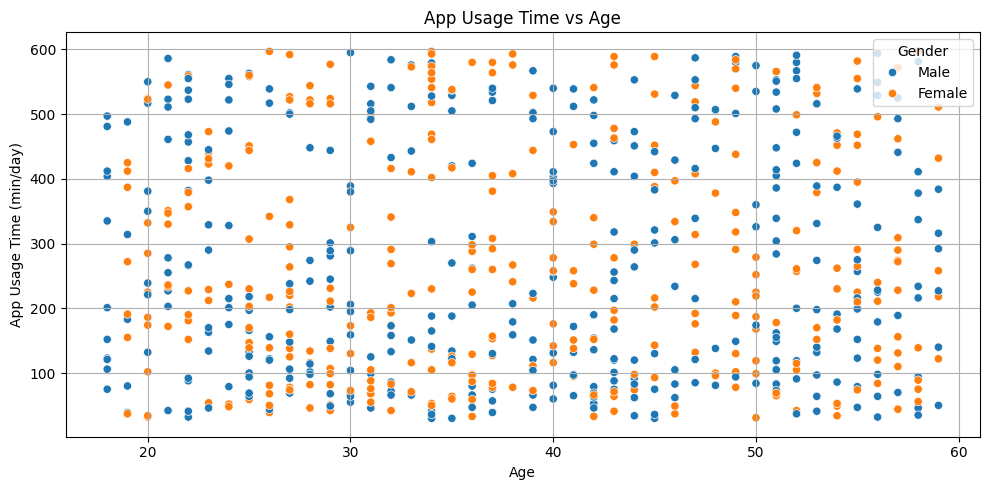

In [2]:
# 🔍 2. App Usage vs Age
plt.figure(figsize=(10,5))
sns.scatterplot(x='Age', y='App Usage Time (min/day)', hue='Gender', data=df)
plt.title('App Usage Time vs Age')
plt.xlabel('Age')
plt.ylabel('App Usage Time (min/day)')
plt.grid(True)
plt.tight_layout()
plt.show()

Caption: Hubungan antara usia pengguna dan waktu penggunaan aplikasi. Pola ini membantu memahami segmentasi usia.

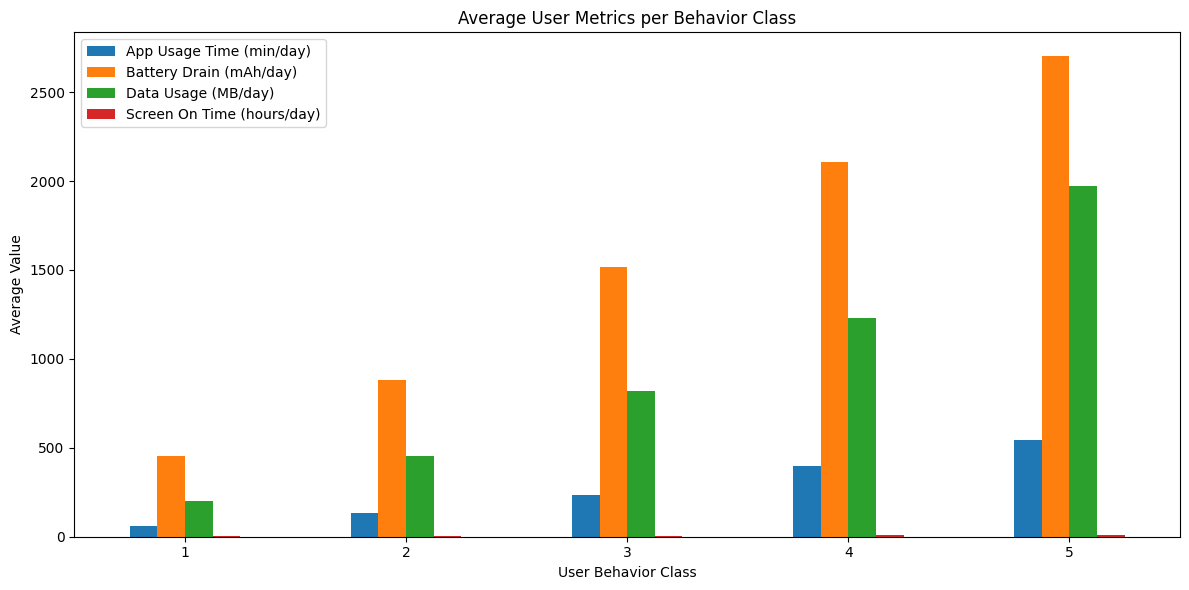

In [3]:
# 🧠 3. Behavior Class Profiles
df.groupby('User Behavior Class')[['App Usage Time (min/day)', 'Battery Drain (mAh/day)',
                                   'Data Usage (MB/day)', 'Screen On Time (hours/day)']].mean().plot(kind='bar', figsize=(12,6))
plt.title('Average User Metrics per Behavior Class')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

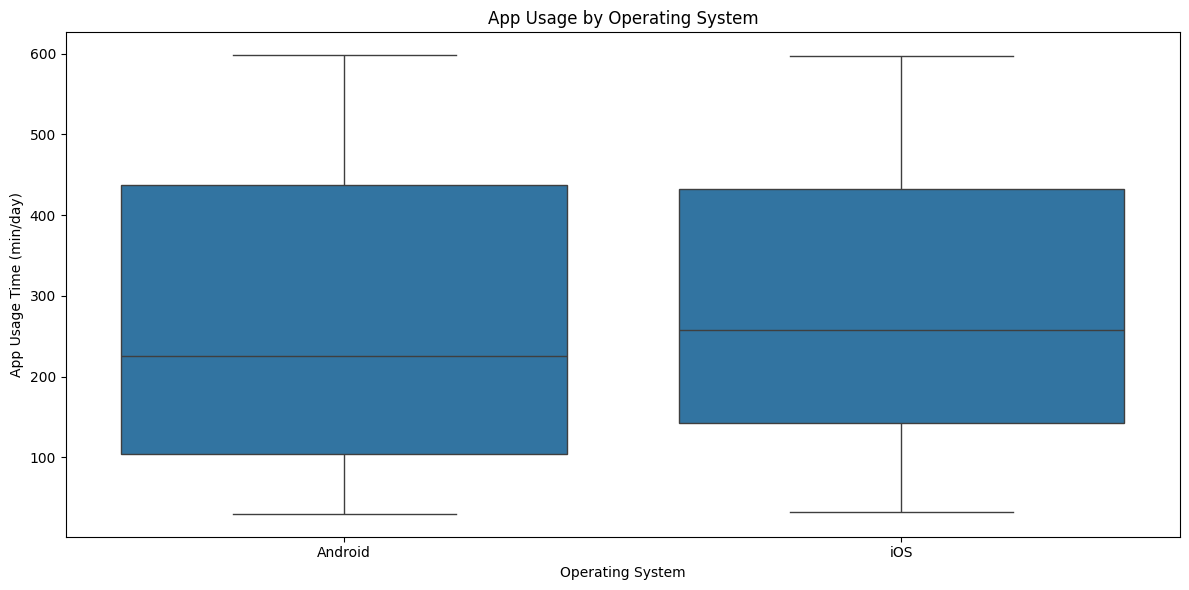

In [6]:
# 📱 4. Android vs iOS Comparison
plt.figure(figsize=(12,6))
sns.boxplot(x='Operating System', y='App Usage Time (min/day)', data=df)
plt.title('App Usage by Operating System')
plt.tight_layout()
plt.show()

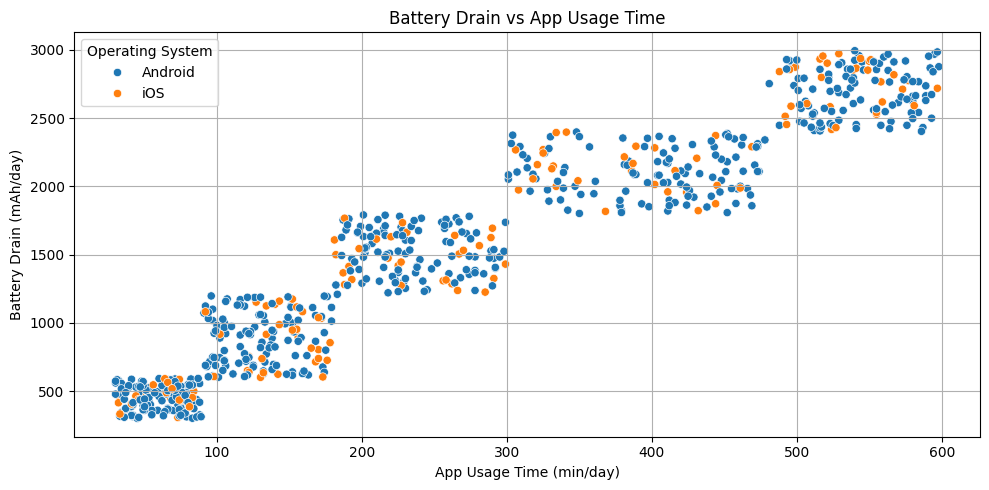

In [7]:
# 🔋 5. Battery Drain vs App Usage
plt.figure(figsize=(10,5))
sns.scatterplot(x='App Usage Time (min/day)', y='Battery Drain (mAh/day)', hue='Operating System', data=df)
plt.title('Battery Drain vs App Usage Time')
plt.grid(True)
plt.tight_layout()
plt.show()

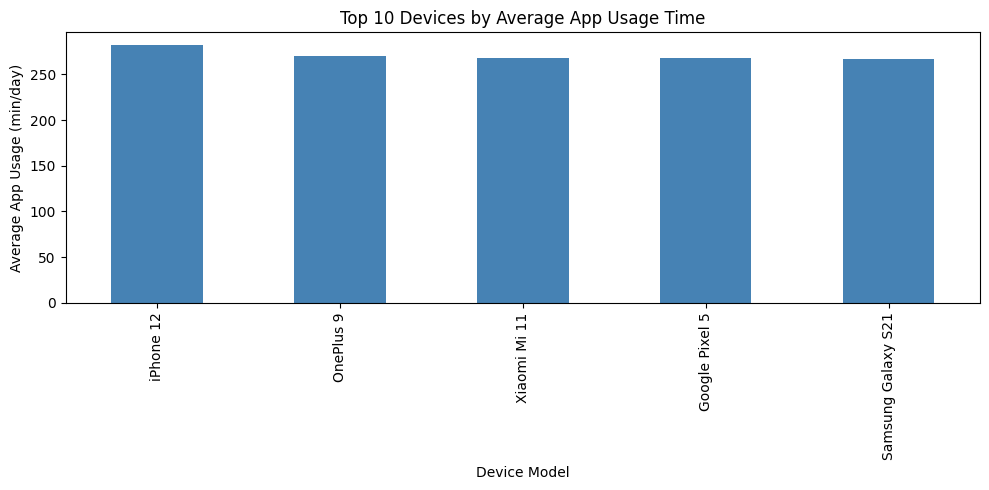

In [8]:
# 📱 6. Top Device Models by Usage
top_devices = df.groupby('Device Model')['App Usage Time (min/day)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_devices.plot(kind='bar', color='steelblue')
plt.title('Top 10 Devices by Average App Usage Time')
plt.ylabel('Average App Usage (min/day)')
plt.tight_layout()
plt.show()

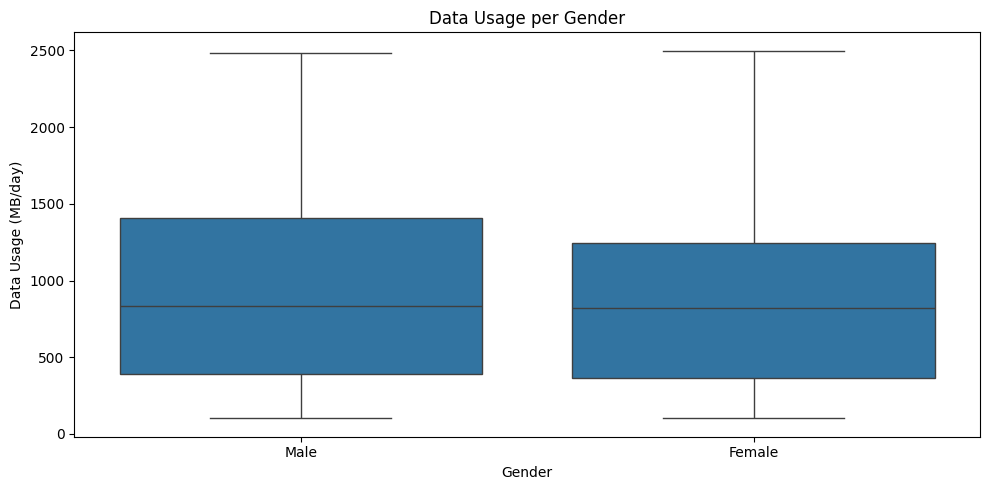

In [9]:
# 🚻 7. Gender-Based Usage Differences
plt.figure(figsize=(10,5))
sns.boxplot(x='Gender', y='Data Usage (MB/day)', data=df)
plt.title('Data Usage per Gender')
plt.tight_layout()
plt.show()

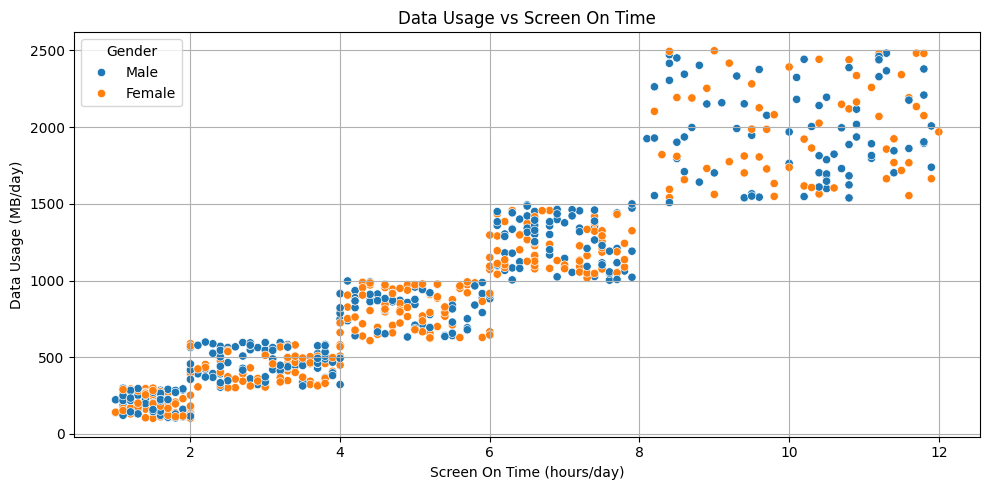

In [10]:
# ⏱️ 8. Screen Time vs Data Usage
plt.figure(figsize=(10,5))
sns.scatterplot(x='Screen On Time (hours/day)', y='Data Usage (MB/day)', hue='Gender', data=df)
plt.title('Data Usage vs Screen On Time')
plt.grid(True)
plt.tight_layout()
plt.show()

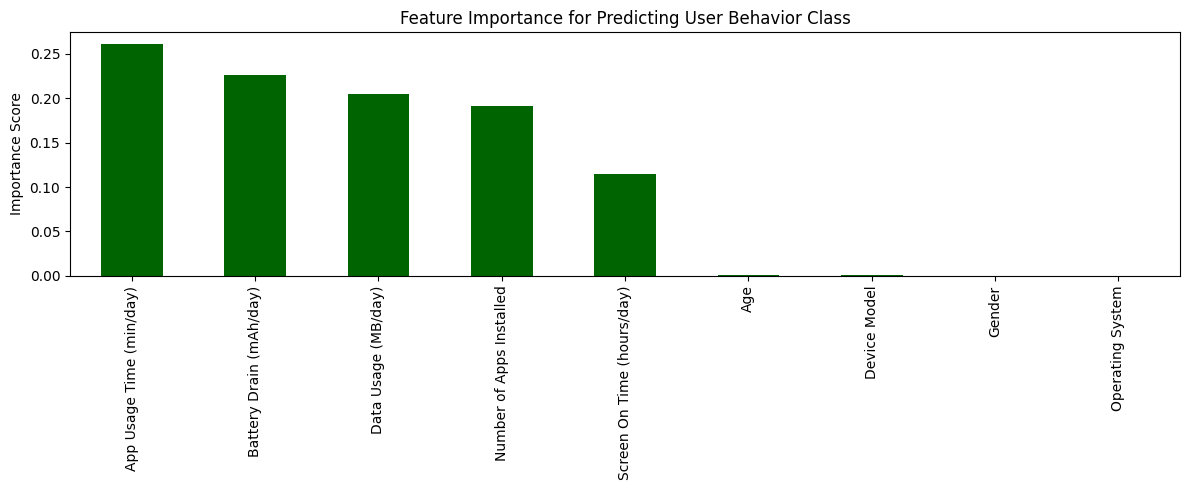

In [11]:
# 🌐 9. Feature Importance (Random Forest) for Behavior Class
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
df_encoded = df.copy()
df_encoded['Gender'] = LabelEncoder().fit_transform(df['Gender'])
df_encoded['Operating System'] = LabelEncoder().fit_transform(df['Operating System'])
df_encoded['Device Model'] = LabelEncoder().fit_transform(df['Device Model'])

X = df_encoded.drop(['User ID', 'User Behavior Class'], axis=1)
y = df_encoded['User Behavior Class']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12,5), color='darkgreen')
plt.title('Feature Importance for Predicting User Behavior Class')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()